In [5]:
import numpy as np
import pandas as pd

In [3]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2607,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Dataset_clean_v2.csv")

c:\Leo_Perso\ENSAE\3A\Advanced ML\Projet ML\Learning-Latent-Football-Team-Strengths\Data\data_cleaning.py:26: DtypeWarning: Columns (139) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(filepath)


In [1]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Dataset_clean_v2.csv")

processer.remove_year("25-26")


# Seasons 2010-11 to 2023-24 in train, season 2024-25 in test
train_df, test_df = processer.split_train_test(test_size=306)

train_data, test_data = processer.get_train_test_data()

In [ ]:
from BradleyTerry_classical.functions import BT_calibrate

# Calibrate Hyperparameter Lambda

Lambda_Chooser = BT_calibrate(train_data=train_data)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

In [2]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


In [ ]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry
import torch

# ==============================================================================
# 2. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==============================================================================
# On charge le fichier final créé précédemment
df = pd.read_csv("Data/dataset_final_training.csv")

# Liste des features (Assurez-vous que ces colonnes existent dans votre CSV)
# Note : on utilise les noms de base, on rajoutera _Home et _Away après
feature_names = [
    'Log_Market_Value',      # Structurel
    'Strength_Rank_Based',   # Historique
    'Pythagorean_Exp',       # Forme théorique
    'Avg_Goals_Scored',      # Attaque
    'Home_Dependency'        # Domicile
]

# Création des matrices X_home, X_away et y
# On prend toutes les données (Train + Test mélangés pour cet exemple simple)
X_home = df[[f"{col}_Home" for col in feature_names]].values.astype(np.float32)
X_away = df[[f"{col}_Away" for col in feature_names]].values.astype(np.float32)
y = df['Target'].values.astype(np.float32)

# ==============================================================================
# 3. ENTRAÎNEMENT
# ==============================================================================
model = NeuralBradleyTerry(input_dim=len(feature_names))
model.fit(X_home, X_away, y, epochs=500)

# ==============================================================================
# 4. OBTENIR LES FORCES (Ce que vous demandez)
# ==============================================================================

def get_season_ranking(model, df_full, target_season, feature_cols):
    """
    Extrait les forces des équipes pour une saison précise.
    """
    # 1. On filtre pour garder une seule ligne par équipe pour cette saison
    # On utilise les infos "Home" pour avoir les stats de l'équipe
    unique_teams = df_full[df_full['Season'] == target_season].drop_duplicates(subset=['HomeTeam'])
    
    if unique_teams.empty:
        print(f"Aucune donnée trouvée pour la saison {target_season}")
        return None

    # 2. Préparation des features de ces équipes
    cols_home = [f"{col}_Home" for col in feature_cols]
    X_teams = unique_teams[cols_home].values.astype(np.float32)

    # 3. Le modèle prédit la force !
    model.eval()
    with torch.no_grad():
        strengths = model.forward(torch.tensor(X_teams)).numpy().flatten()
        
        strengths = strengths - np.mean(strengths)  # Centrage pour interprétation relative

        print(f"Moyennes des forces {np.mean(strengths)}")
    
    # 4. Création du tableau de résultat
    ranking = pd.DataFrame({
        'Team': unique_teams['HomeTeam'],
        'Neural_Strength': strengths
        })
    
        # On trie du plus fort au plus faible
    return ranking.sort_values(by='Neural_Strength', ascending=False)

# --- EXEMPLE : CLASSEMENT POUR LA DERNIÈRE SAISON DU FICHIER ---
last_season = '2024-2025' # Ex: "22-23" ou "2022" selon votre format
print(f"\n--- CLASSEMENT NEURAL POUR LA SAISON {last_season} ---")

ranking = get_season_ranking(model, df, last_season, feature_names)

ranking

In [7]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate = BT_evaluate_strengths(BT_results=strength, NBTR_results=ranking, test_df=test_df)

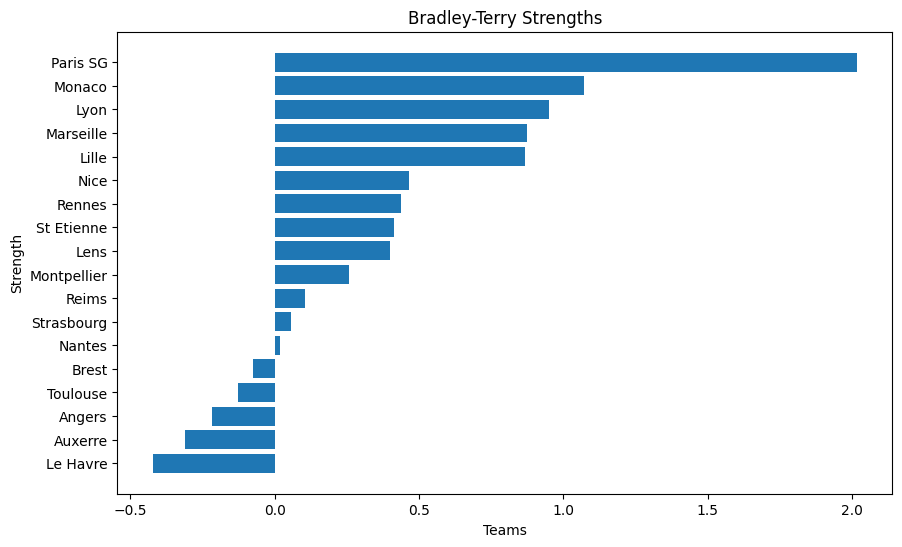

In [8]:
Evaluate.plot_strengths(model='BT')

In [9]:
Evaluate.spearman_correlation()

{'correlation': np.float64(0.6670128020188779),
 'pvalue': np.float64(0.002497188896711762),
 'ci_lower': np.float64(0.23712429580389305),
 'ci_upper': np.float64(0.9167090255721111)}